In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
data_train = pd.read_csv("../data/KDDTrain+.txt")

In [3]:
columns = [
    'duration',
    'protocol_type',
    'service',
    'flag',
    'src_bytes',
    'dst_bytes',
    'land',
    'wrong_fragment',
    'urgent',
    'hot',
    'num_failed_logins',
    'logged_in',
    'num_compromised',
    'root_shell',
    'su_attempted',
    'num_root',
    'num_file_creations',
    'num_shells',
    'num_access_files',
    'num_outbound_cmds',
    'is_host_login',
    'is_guest_login',
    'count',
    'srv_count',
    'serror_rate',
    'srv_serror_rate',
    'rerror_rate',
    'srv_rerror_rate',
    'same_srv_rate',
    'diff_srv_rate',
    'srv_diff_host_rate',
    'dst_host_count',
    'dst_host_srv_count',
    'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate',
    'class',
    'difficulty'
]
data_train.columns = columns

In [4]:
data_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [5]:
data_train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125972.000000,1.259720e+05,1.259720e+05,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,...,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000
mean,287.146929,4.556710e+04,1.977927e+04,0.000198,0.022688,0.000111,0.204411,0.001222,0.395739,0.279253,...,115.653725,0.521244,0.082952,0.148379,0.032543,0.284455,0.278487,0.118832,0.120241,19.504056
std,2604.525522,5.870354e+06,4.021285e+06,0.014086,0.253531,0.014366,2.149977,0.045239,0.489011,23.942137,...,110.702886,0.448950,0.188922,0.308998,0.112564,0.444785,0.445670,0.306559,0.319460,2.291512
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


              class  count
11           normal  67342
9           neptune  41214
17            satan   3633
5           ipsweep   3599
15        portsweep   2931
18            smurf   2646
10             nmap   1493
0              back    956
20         teardrop    892
21      warezclient    890
14              pod    201
3      guess_passwd     53
1   buffer_overflow     30
22      warezmaster     20
6              land     18
4              imap     11
16          rootkit     10
7        loadmodule      9
2         ftp_write      8
8          multihop      7
13              phf      4
12             perl      3
19              spy      2


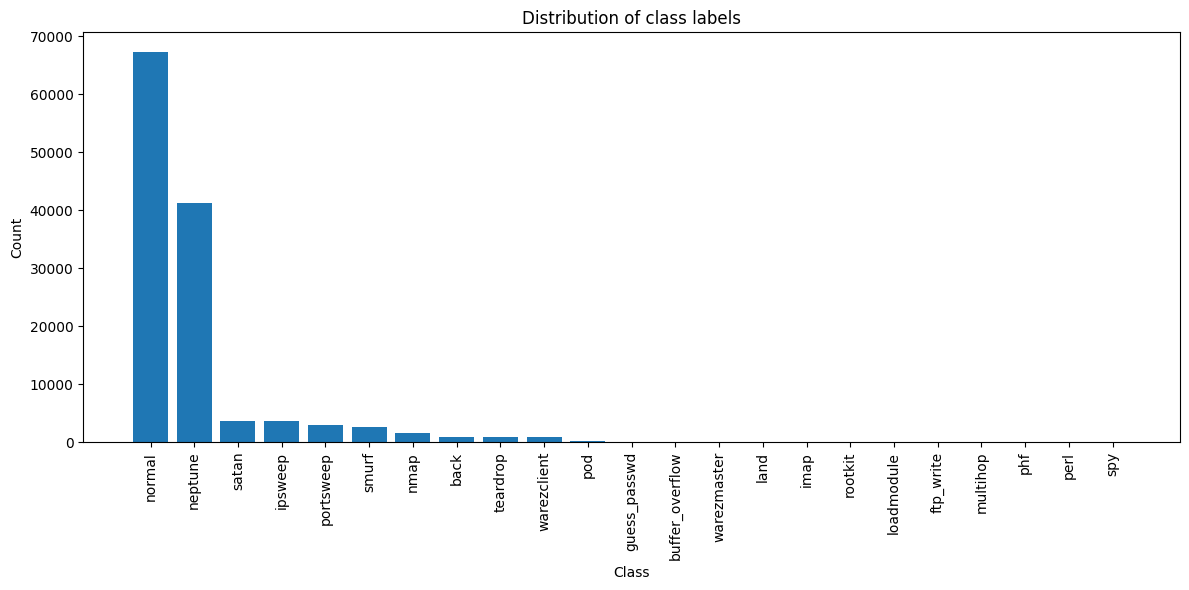

In [6]:
# Distribution of the "class" column
class_counts = (
    data_train
    .groupby('class')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print(class_counts)

# Plot distribution
plt.figure(figsize=(12, 6))
plt.bar(class_counts['class'].astype(str), class_counts['count'])
plt.xticks(rotation=90)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of class labels')
plt.tight_layout()
plt.show()

In [7]:
attack_mapping = {
    'normal': 'Normal',
    
    'neptune': 'DoS', 'smurf': 'DoS', 'back': 'DoS', 'teardrop': 'DoS', 'pod': 'DoS', 'land': 'DoS',
    
    'satan': 'Probe', 'ipsweep': 'Probe', 'portsweep': 'Probe', 'nmap': 'Probe',
    
    'warezclient': 'R2L', 'guess_passwd': 'R2L', 'warezmaster': 'R2L', 'imap': 'R2L', 

    'ftp_write': 'R2L', 'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L',

    'buffer_overflow': 'U2R', 'rootkit': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R'
}

data_train['mapped_class'] = data_train['class'].map(attack_mapping)


In [8]:
data_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty,mapped_class
0,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15,Normal
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19,DoS
2,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21,Normal
3,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21,Normal
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21,DoS


  mapped_class  count
1       Normal  67342
0          DoS  45927
2        Probe  11656
3          R2L    995
4          U2R     52


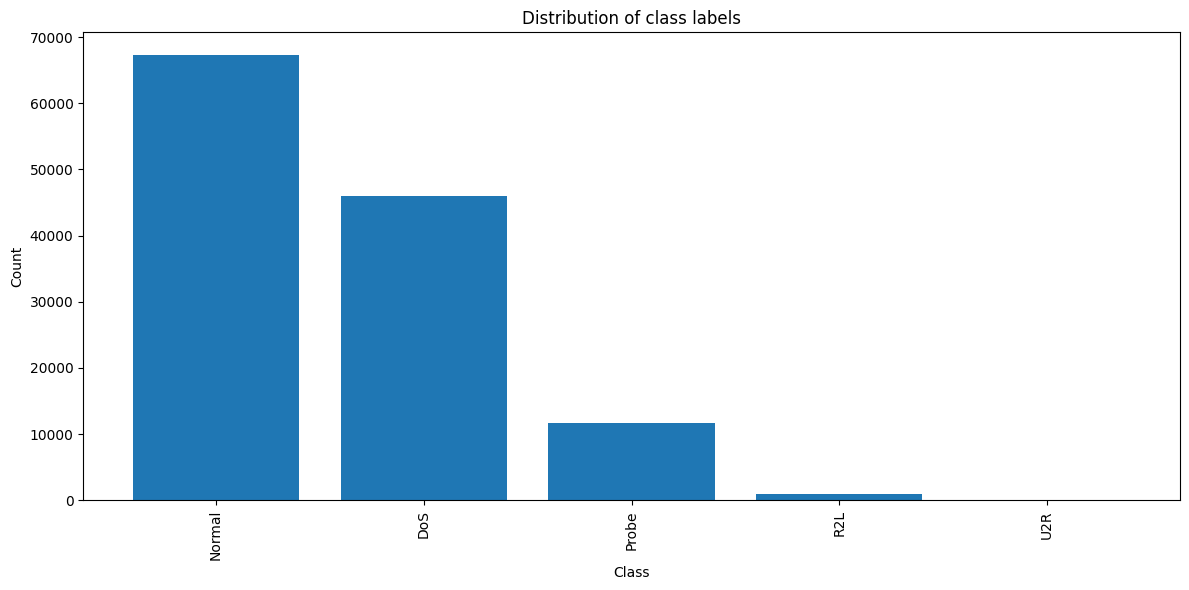

In [9]:
# Distribution of the "class" column
class_counts = (
    data_train
    .groupby('mapped_class')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print(class_counts)

# Plot distribution
plt.figure(figsize=(12, 6))
plt.bar(class_counts['mapped_class'].astype(str), class_counts['count'])
plt.xticks(rotation=90)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of class labels')
plt.tight_layout()
plt.show()

In [10]:
# Calculate percentage distribution for 'mapped_class'
mapped_class_percentage = (
    data_train['mapped_class'].value_counts(normalize=True) * 100
).reset_index()
mapped_class_percentage.columns = ['mapped_class', 'percentage']
print("Percentage distribution for mapped_class:")
print(mapped_class_percentage)

# Calculate percentage distribution for original 'class'
class_percentage = (
    data_train['class'].value_counts(normalize=True) * 100
).reset_index()
class_percentage.columns = ['class', 'percentage']
print("\nPercentage distribution for class:")
print(class_percentage)


Percentage distribution for mapped_class:
  mapped_class  percentage
0       Normal   53.457911
1          DoS   36.458102
2        Probe    9.252850
3          R2L    0.789858
4          U2R    0.041279

Percentage distribution for class:
              class  percentage
0            normal   53.457911
1           neptune   32.716794
2             satan    2.883974
3           ipsweep    2.856984
4         portsweep    2.326708
5             smurf    2.100467
6              nmap    1.185184
7              back    0.758899
8          teardrop    0.708094
9       warezclient    0.706506
10              pod    0.159559
11     guess_passwd    0.042073
12  buffer_overflow    0.023815
13      warezmaster    0.015877
14             land    0.014289
15             imap    0.008732
16          rootkit    0.007938
17       loadmodule    0.007144
18        ftp_write    0.006351
19         multihop    0.005557
20              phf    0.003175
21             perl    0.002381
22              spy    0

In [11]:
# Check how many unique values exist in some categorical features
categorical_features = ['service', 'protocol_type', 'flag']
for feature in categorical_features:
    unique_values = data_train[feature].unique()
    print(f"Feature '{feature}' has {len(unique_values)} unique values.")
    print(f"Example values: {unique_values[:10]}")
    print()

Feature 'service' has 70 unique values.
Example values: ['other' 'private' 'http' 'remote_job' 'ftp_data' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet']

Feature 'protocol_type' has 3 unique values.
Example values: ['udp' 'tcp' 'icmp']

Feature 'flag' has 11 unique values.
Example values: ['SF' 'S0' 'REJ' 'RSTR' 'SH' 'RSTO' 'S1' 'RSTOS0' 'S3' 'S2']



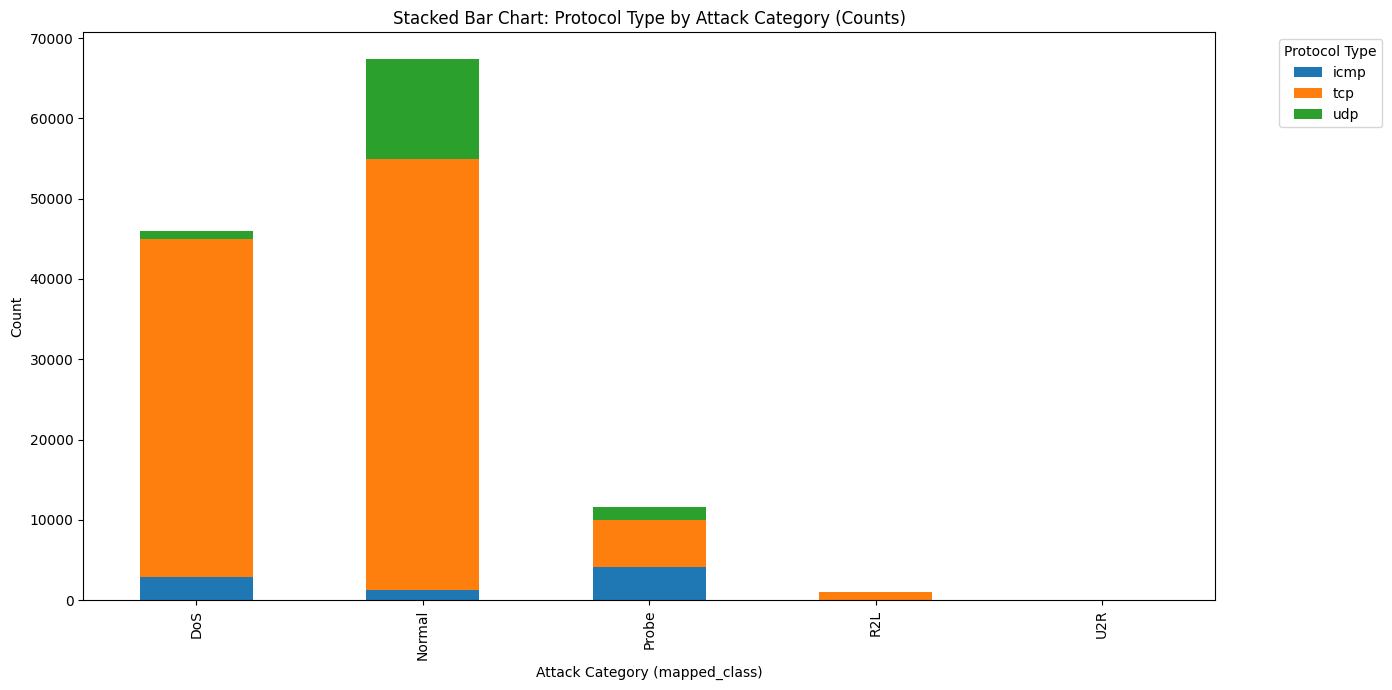

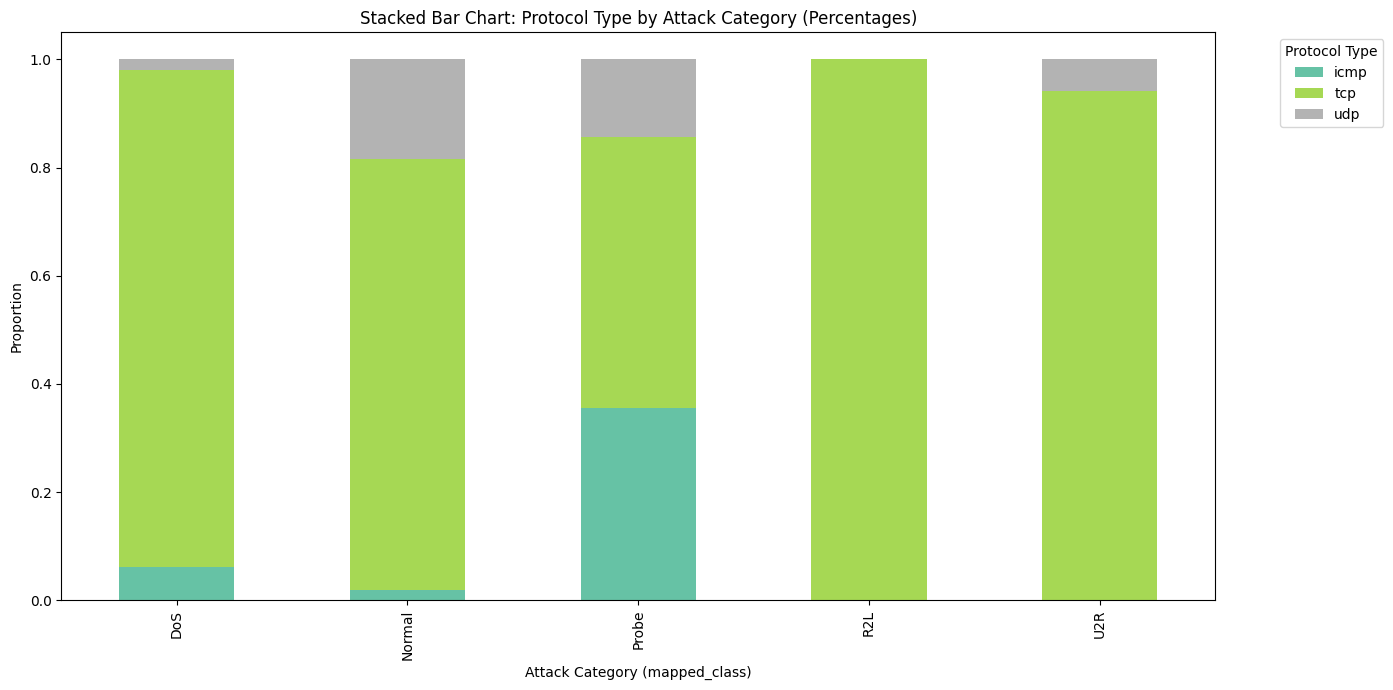

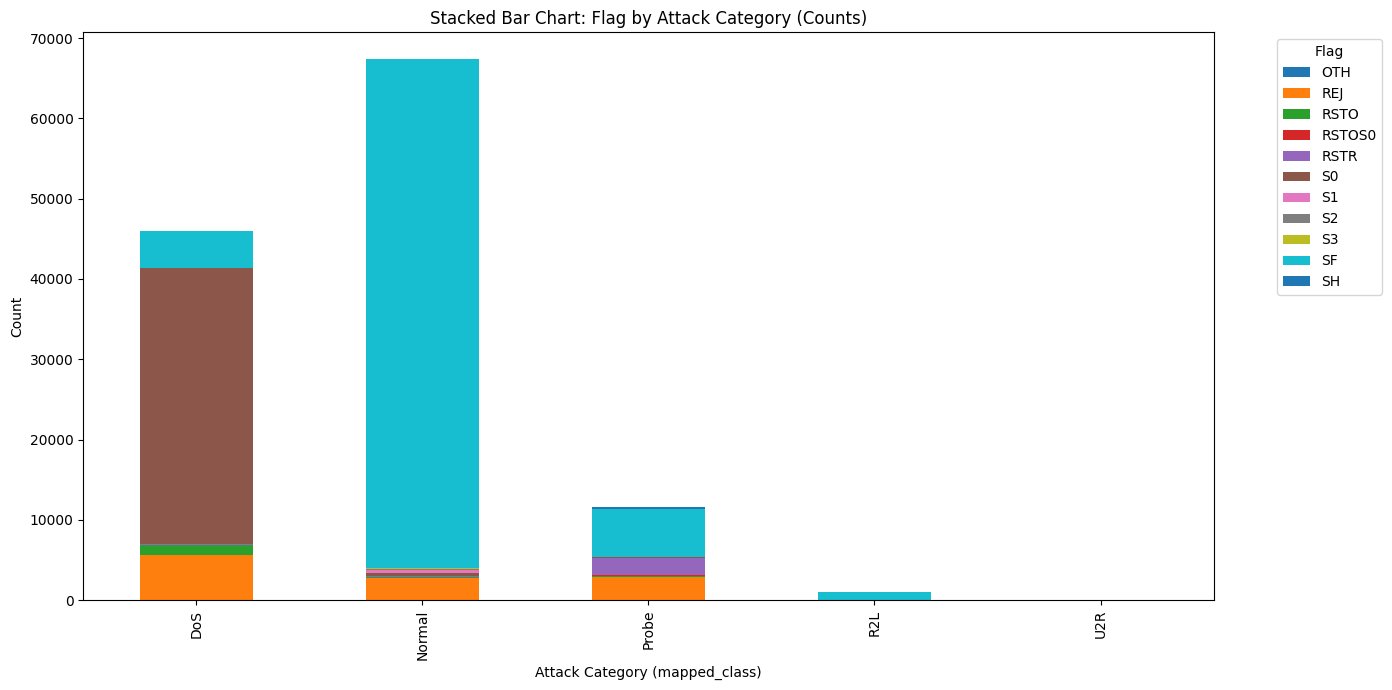

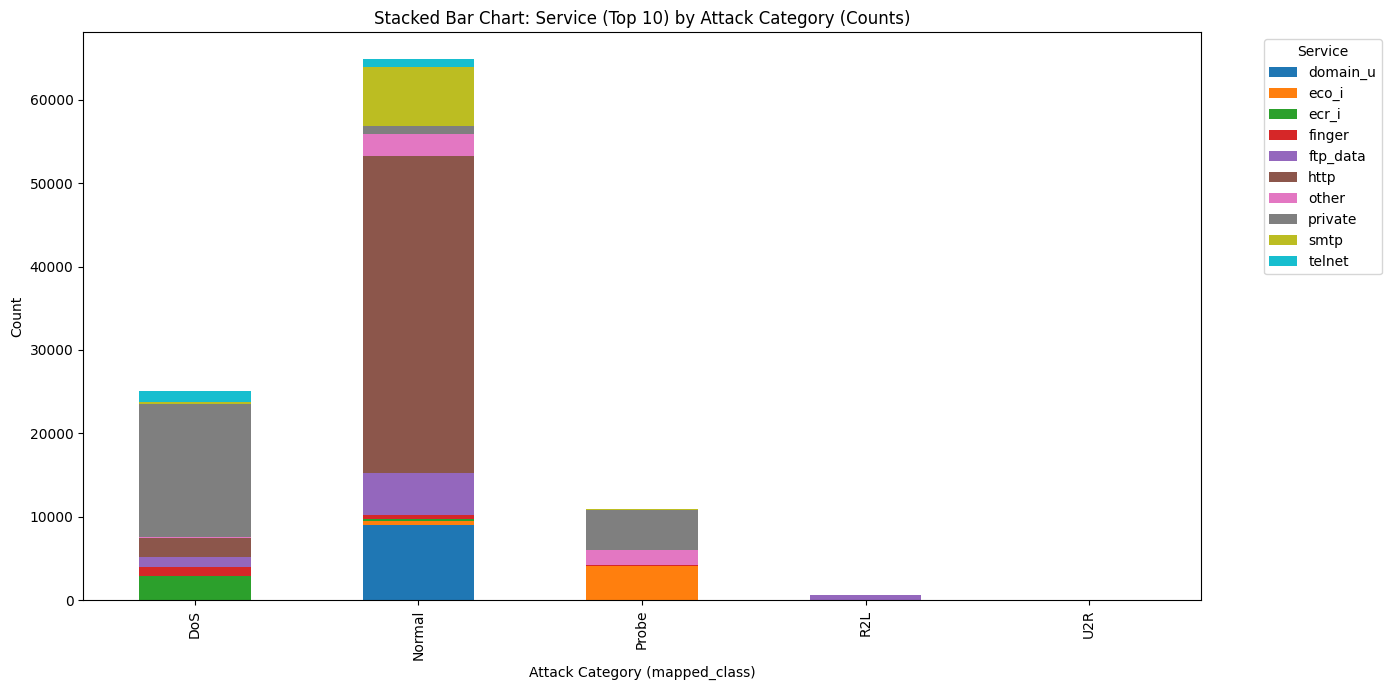

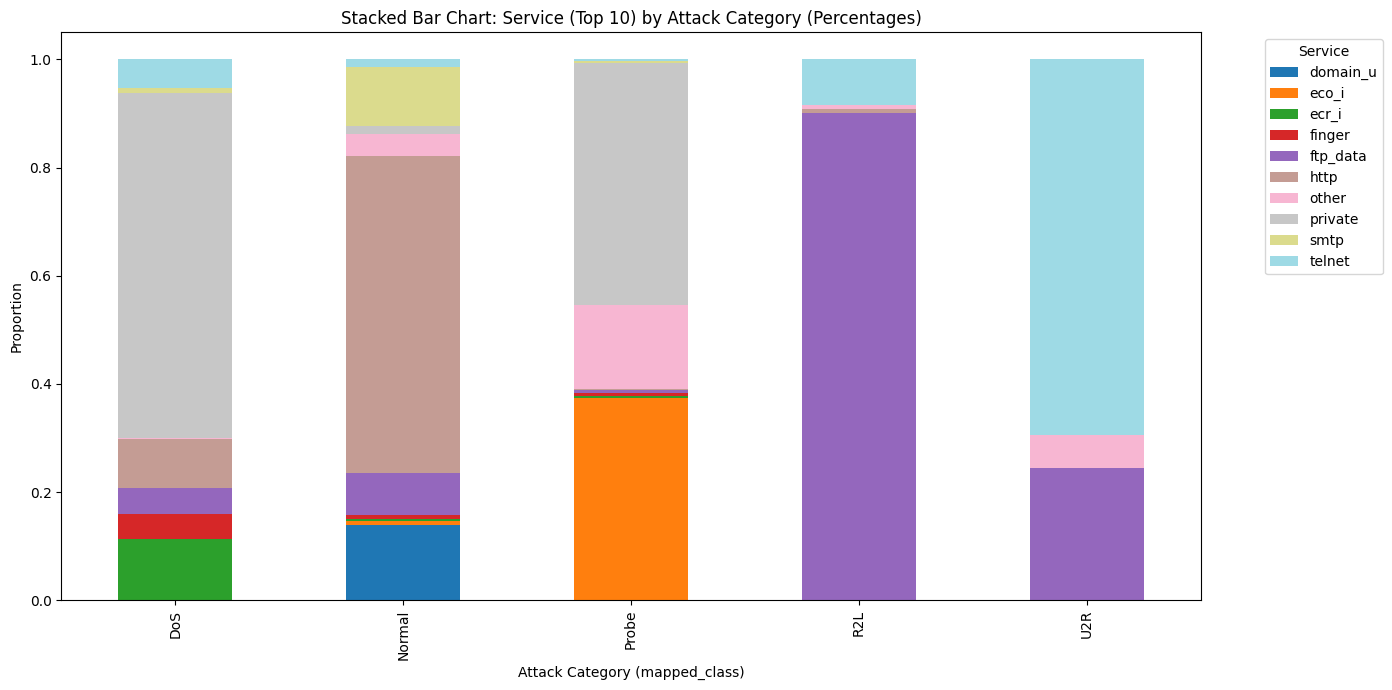

In [12]:
import matplotlib.pyplot as plt

# We'll look at how protocol_type is distributed across mapped_class attack categories
# (e.g., which protocol is most common in DoS, Probe, etc.)

# Set up figure for protocol_type vs mapped_class
protocol_vs_class = (
    data_train.groupby(['mapped_class', 'protocol_type'])
    .size()
    .unstack(fill_value=0)
)

protocol_vs_class_percent = protocol_vs_class.div(protocol_vs_class.sum(axis=1), axis=0)

protocol_vs_class.plot(kind="bar", stacked=True, figsize=(14,7))
plt.title("Stacked Bar Chart: Protocol Type by Attack Category (Counts)")
plt.ylabel("Count")
plt.xlabel("Attack Category (mapped_class)")
plt.legend(title='Protocol Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

protocol_vs_class_percent.plot(kind="bar", stacked=True, figsize=(14,7), colormap='Set2')
plt.title("Stacked Bar Chart: Protocol Type by Attack Category (Percentages)")
plt.ylabel("Proportion")
plt.xlabel("Attack Category (mapped_class)")
plt.legend(title='Protocol Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Let's also do the same for 'flag' and 'service' but limit to the top N services for readability.
# For 'flag'
flag_vs_class = (
    data_train.groupby(['mapped_class', 'flag'])
    .size()
    .unstack(fill_value=0)
)

flag_vs_class_percent = flag_vs_class.div(flag_vs_class.sum(axis=1), axis=0)

flag_vs_class.plot(kind="bar", stacked=True, figsize=(14,7))
plt.title("Stacked Bar Chart: Flag by Attack Category (Counts)")
plt.ylabel("Count")
plt.xlabel("Attack Category (mapped_class)")
plt.legend(title='Flag', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# For 'service' (show only the top 10 services for readability)
top_services = data_train['service'].value_counts().nlargest(10).index
service_data = data_train[data_train['service'].isin(top_services)]

service_vs_class = (
    service_data.groupby(['mapped_class', 'service'])
    .size()
    .unstack(fill_value=0)
)

service_vs_class_percent = service_vs_class.div(service_vs_class.sum(axis=1), axis=0)

service_vs_class.plot(kind="bar", stacked=True, figsize=(14,7))
plt.title("Stacked Bar Chart: Service (Top 10) by Attack Category (Counts)")
plt.ylabel("Count")
plt.xlabel("Attack Category (mapped_class)")
plt.legend(title='Service', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

service_vs_class_percent.plot(kind="bar", stacked=True, figsize=(14,7), colormap='tab20')
plt.title("Stacked Bar Chart: Service (Top 10) by Attack Category (Percentages)")
plt.ylabel("Proportion")
plt.xlabel("Attack Category (mapped_class)")
plt.legend(title='Service', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [13]:
# Zero-variance check: Find columns with a single constant value (variance of 0)
zero_var_cols = []
for col in data_train.select_dtypes(include=[float, int, 'bool']).columns:
    if data_train[col].nunique(dropna=False) == 1:
        zero_var_cols.append(col)

# For categorical/object columns, also consider if only one unique value present
cat_cols = data_train.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    if data_train[col].nunique(dropna=False) == 1:
        zero_var_cols.append(col)

print("Columns with zero variance (single unique value):", zero_var_cols)


Columns with zero variance (single unique value): ['num_outbound_cmds']


In [14]:
data_train = data_train.drop(columns=zero_var_cols)

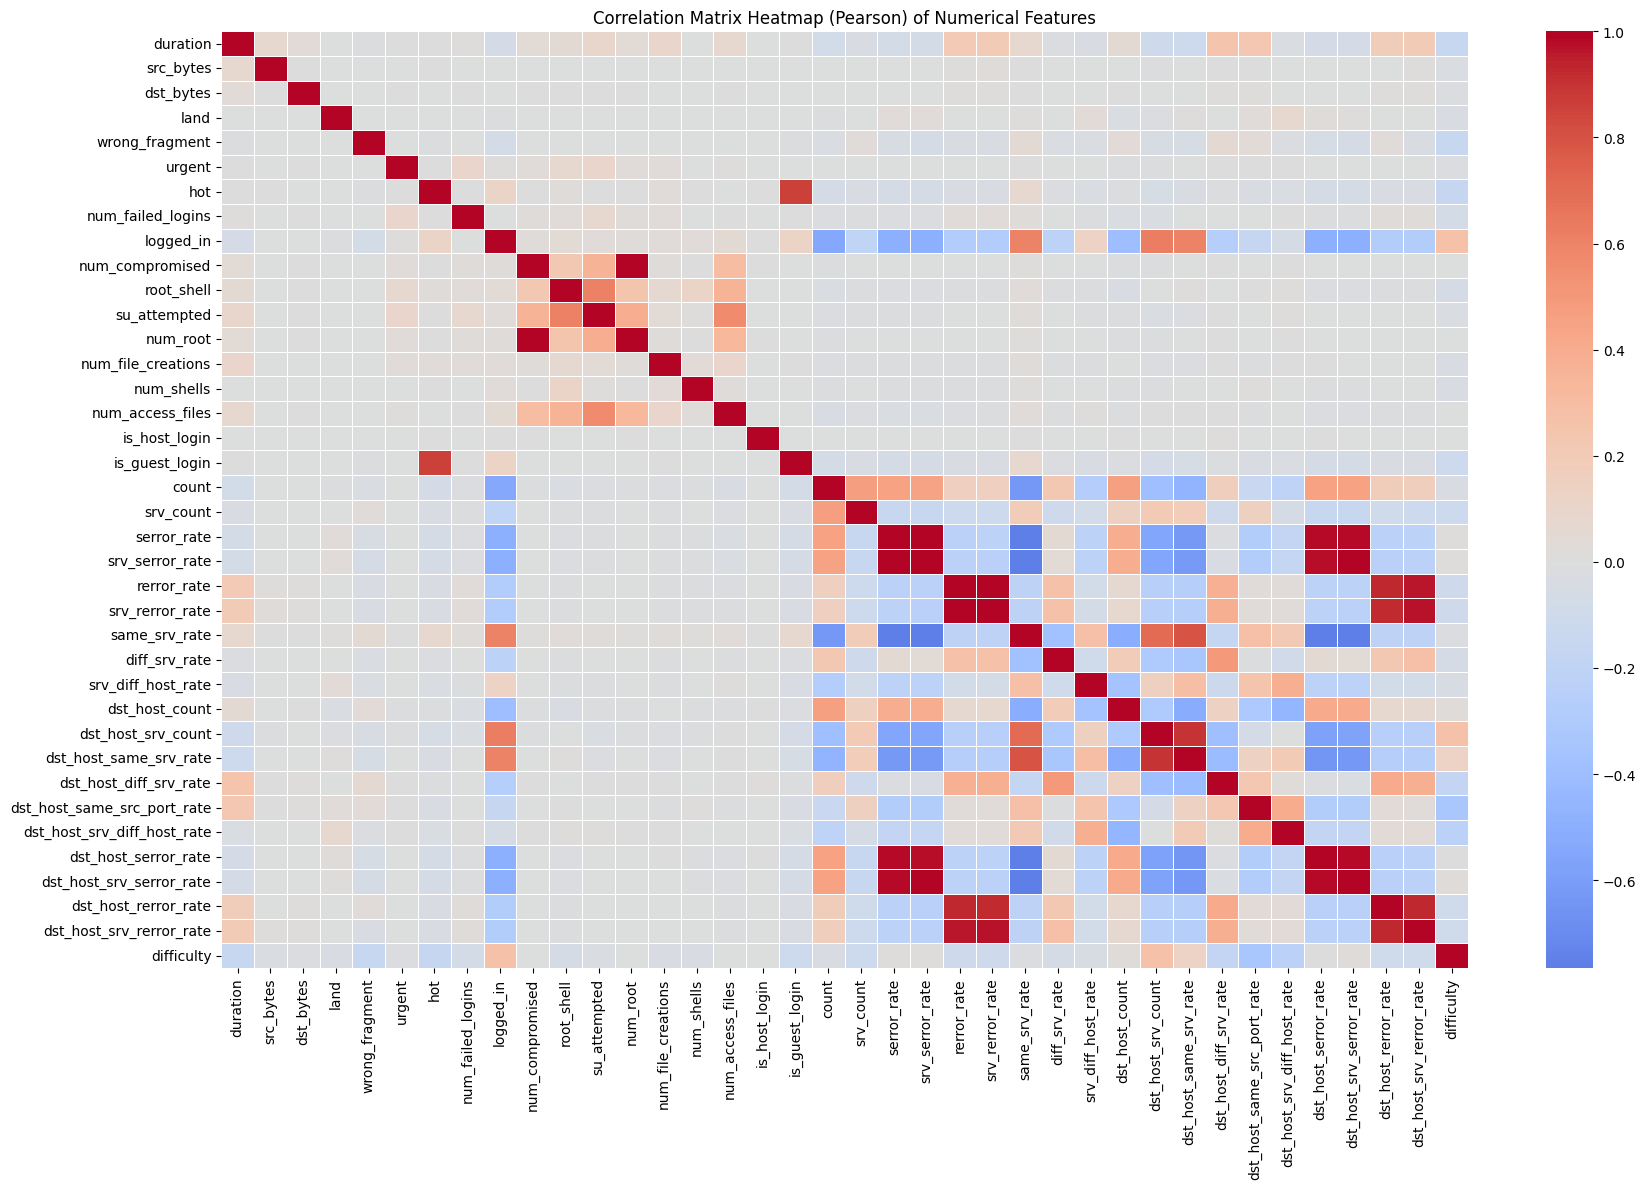

In [15]:

# Select only numerical columns for correlation calculation
numerical_cols = data_train.select_dtypes(include=['float64', 'int64', 'float32', 'int32', 'float', 'int', 'bool']).columns

# Compute the Pearson correlation matrix (can switch to 'spearman' if desired)
corr_matrix = data_train[numerical_cols].corr(method='pearson')

# Plot the heatmap
plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Matrix Heatmap (Pearson) of Numerical Features")
plt.tight_layout()
plt.show()

In [16]:
# Find all pairs of different columns with correlation greater than 0.8 or less than -0.8 (excluding self-correlation)
corr_matrix_no_self = corr_matrix.copy()
np.fill_diagonal(corr_matrix_no_self.values, np.nan)  # Ignore diagonal/self-correlation

# Unstack into Series for easier pairwise comparison
corr_pairs = corr_matrix_no_self.unstack()
corr_pairs = corr_pairs.dropna()
# Remove self-correlation and duplicate pairs (keep only one of (a,b) or (b,a))
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs[~corr_pairs.index.duplicated(keep='first')]

# Find pairs with correlation > 0.8 or < -0.8
high_corr_pairs = corr_pairs[(corr_pairs > 0.8) | (corr_pairs < -0.8)]

# Format the results
high_corr_list = []
for (col1, col2), corr_val in high_corr_pairs.items():
    high_corr_list.append((col1, col2, corr_val))

print("Pairs with correlation > 0.8 or < -0.8 (excluding self-correlation):")
for i, (col1, col2, corr_val) in enumerate(high_corr_list, 1):
    print(f"{i:2d}. {col1:30s} <-> {col2:30s}: {corr_val:+.4f}")


Pairs with correlation > 0.8 or < -0.8 (excluding self-correlation):
 1. hot                            <-> is_guest_login                : +0.8603
 2. num_compromised                <-> num_root                      : +0.9988
 3. num_root                       <-> num_compromised               : +0.9988
 4. is_guest_login                 <-> hot                           : +0.8603
 5. serror_rate                    <-> srv_serror_rate               : +0.9933
 6. serror_rate                    <-> dst_host_serror_rate          : +0.9794
 7. serror_rate                    <-> dst_host_srv_serror_rate      : +0.9811
 8. srv_serror_rate                <-> serror_rate                   : +0.9933
 9. srv_serror_rate                <-> dst_host_serror_rate          : +0.9776
10. srv_serror_rate                <-> dst_host_srv_serror_rate      : +0.9863
11. rerror_rate                    <-> srv_rerror_rate               : +0.9890
12. rerror_rate                    <-> dst_host_rerror_rate   

In [17]:
# 1. Sadece sayısal sütunların korelasyon matrisini hesapla (mutlak değer olarak)
# (Korelasyonun negatif veya pozitif olması fark etmez, güçlüyse silinmeli)
# Sadece sayısal sütunları seç
numeric_cols = data_train.select_dtypes(include=[np.number]).columns
corr_matrix = data_train[numeric_cols].corr().abs()

# 2. Matrisin sadece üst üçgenini al (Aynı çiftleri iki kez kontrol etmemek için)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Eşik değerini (Threshold) 0.90 olarak belirle ve silinecekleri bul
threshold = 0.6
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

print(f"Silinecek yüksek korelasyonlu özellik sayısı: {len(to_drop)}")
print(f"Silinen özellikler: {to_drop}")

# 4. Bu özellikleri hem Train hem de Test setinden sil
data_train_reduced = data_train.drop(columns=to_drop)

print(f"Kalan net özellik sayısı: {data_train_reduced.shape[1]}")

Silinecek yüksek korelasyonlu özellik sayısı: 12
Silinen özellikler: ['su_attempted', 'num_root', 'is_guest_login', 'srv_serror_rate', 'srv_rerror_rate', 'same_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
Kalan net özellik sayısı: 31


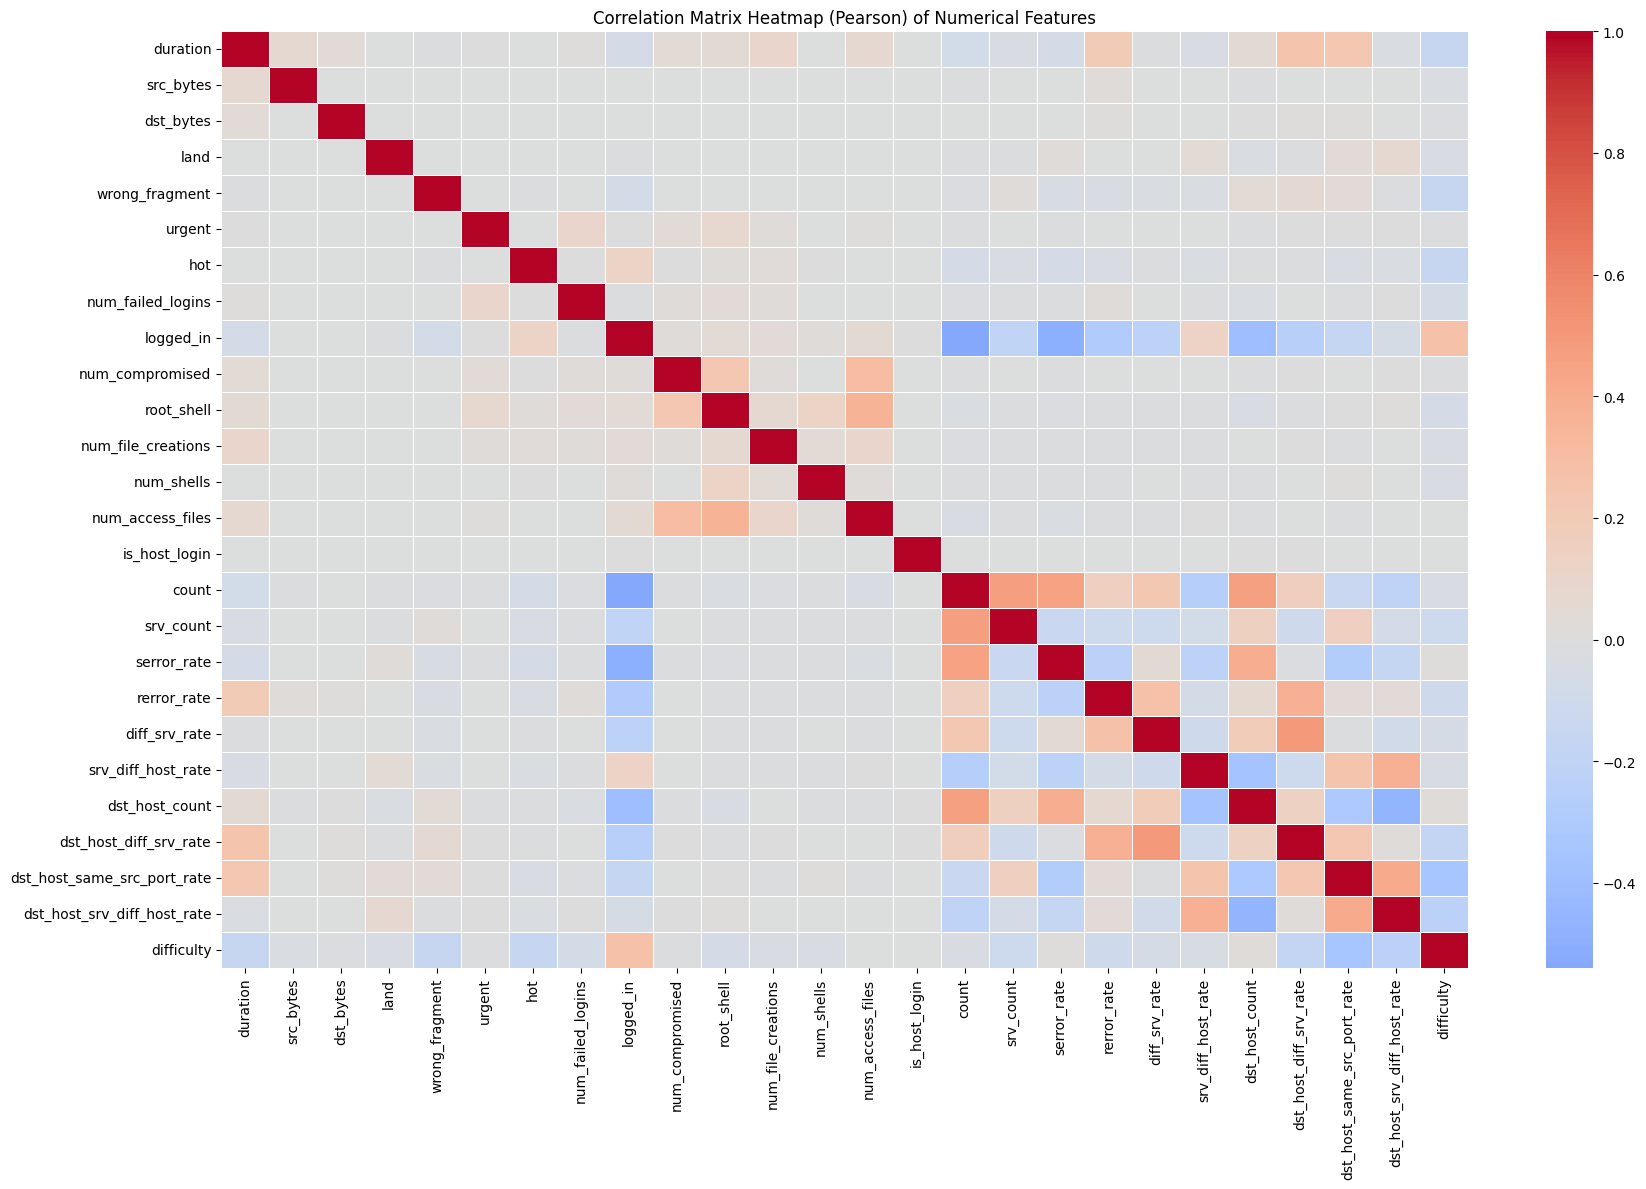

In [18]:

# Select only numerical columns for correlation calculation
numerical_cols = data_train_reduced.select_dtypes(include=['float64', 'int64', 'float32', 'int32', 'float', 'int', 'bool']).columns

# Compute the Pearson correlation matrix (can switch to 'spearman' if desired)
corr_matrix = data_train_reduced[numerical_cols].corr(method='pearson')

# Plot the heatmap
plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Matrix Heatmap (Pearson) of Numerical Features")
plt.tight_layout()
plt.show()

In [19]:
# Find all pairs of different columns with correlation greater than 0.6 or less than -0.6 (excluding self-correlation)
corr_matrix_no_self = corr_matrix.copy()
np.fill_diagonal(corr_matrix_no_self.values, np.nan)  # Ignore diagonal/self-correlation

# Unstack into Series for easier pairwise comparison
corr_pairs = corr_matrix_no_self.unstack()
corr_pairs = corr_pairs.dropna()
# Remove self-correlation and duplicate pairs (keep only one of (a,b) or (b,a))
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs[~corr_pairs.index.duplicated(keep='first')]

# Find pairs with correlation > 0.6 or < -0.6
high_corr_pairs = corr_pairs[(corr_pairs > 0.6) | (corr_pairs < -0.6)]

# Format the results
high_corr_list = []
for (col1, col2), corr_val in high_corr_pairs.items():
    high_corr_list.append((col1, col2, corr_val))

print("Pairs with correlation > 0.6 or < -0.6 (excluding self-correlation):")
for i, (col1, col2, corr_val) in enumerate(high_corr_list, 1):
    print(f"{i:2d}. {col1:30s} <-> {col2:30s}: {corr_val:+.4f}")

Pairs with correlation > 0.6 or < -0.6 (excluding self-correlation):


In [20]:
data_train_reduced.columns.size

31

In [21]:
categorical_cols = data_train_reduced.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical features and their unique categories:\n")
for col in categorical_cols:
    categories = data_train_reduced[col].unique()
    print(f"{col}: {categories}")

# Optionally, to get value counts as well:
# for col in categorical_cols:
#     print(f"\n{col} value counts:")
#     print(data_train_reduced[col].value_counts())

Categorical features and their unique categories:

protocol_type: ['udp' 'tcp' 'icmp']
service: ['other' 'private' 'http' 'remote_job' 'ftp_data' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']
flag: ['SF' 'S0' 'REJ' 'RSTR' 'SH' 'RSTO' 'S1' 'RSTOS0' 'S3' 'S2' 'OTH']
class: ['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'